# CheckCorrectnessPerspectiveAlgorithm

Verifica offline dell'**algoritmo per il nuovo sottoproblema per-peso** di METaQ, dopo aver integrato la
*Perspective Reformulation* del ridge (indicazione del Prof. Frangioni).

## Il nuovo sottoproblema (per un singolo peso w, dati gli xi_k)

$$\min_{x_k \ge 0}\; \sum_k \xi_k x_k \;+\; T_1\,\frac{w^2}{y} \;+\; T_3\, y \qquad (y=\textstyle\sum_k x_k) \qquad \text{s.t. } \sum_k v_k x_k = w,\; y \le 1$$

## L'algoritmo che verifichiamo
1. **Osservazione:** `T1*w^2/y + T3*y` dipende **solo dalla massa totale** y, non da come la distribuisci.
2. **kappa(y)** = min del pezzo lineare a massa fissata `y`. Vale l'identita' di scala
   **kappa(y) = y * kappa(1)[target = w/y]**  → si risolve col **vecchio knapsack**, chiamato su target riscalato.
3. **passo esterno:** minimizzo `G(y) = kappa(y) + T1*w^2/y + T3*y` su `y in [ymin, 1]` (convesso in y);
   su ogni tratto lineare di kappa (pendenza s): `y = |w|*sqrt(T1/(s+T3))`.
4. **subgradiente** (per SGD): `beta = beta_old(w/y*) + 2*T1*w/y*`.

## Ground truth
Usiamo **cvxpy** per risolvere il sottoproblema completo direttamente (con `inv_pos` per il termine `w^2/y`)
e confrontiamo. Per kappa usiamo anche `scipy.linprog`.


In [1]:
import numpy as np
from scipy.optimize import linprog, minimize_scalar
import cvxpy as cp
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
print('cvxpy', cp.__version__)

cvxpy 1.5.3


## Setup: griglia, xi random, e i solver (kappa, ground-truth cvxpy, il mio metodo)

In [2]:
# ---------- setup ----------
def make_grid(C=16, lo=-0.55, hi=0.58, gap_ratio=0.05):
    r = 0.5*(hi-lo); gap = gap_ratio*r
    n_neg = C//2; n_pos = C-n_neg
    neg = np.linspace(min(lo,-gap), -gap, n_neg)
    pos = np.linspace(gap, max(hi,gap), n_pos)
    return np.concatenate([neg, pos]).astype(float)

def random_xi(C, rng, scale=40.0, shift=-20.0):
    return (np.sort(rng.random(C))*scale + shift).astype(float)

# ---------- kappa(1) al target wp (massa unitaria = vecchio sottoproblema) ----------
def kappa1(wp, xi, v):
    C = len(v)
    A_eq = np.vstack([v, np.ones(C)]); b_eq = np.array([wp, 1.0])
    res = linprog(c=xi, A_eq=A_eq, b_eq=b_eq, bounds=[(0, None)]*C, method='highs')
    return res.fun if res.success else np.inf

# ---------- kappa(y) direttamente (massa y) ----------
def kappa_direct(y, w, xi, v):
    C = len(v)
    A_eq = np.vstack([v, np.ones(C)]); b_eq = np.array([w, y])
    res = linprog(c=xi, A_eq=A_eq, b_eq=b_eq, bounds=[(0, None)]*C, method='highs')
    return res.fun if res.success else np.inf

# ---------- GROUND TRUTH: sottoproblema completo via cvxpy ----------
def gt_full(w, xi, v, T1, T3):
    C = len(v)
    x = cp.Variable(C, nonneg=True); ysum = cp.sum(x)
    obj = cp.Minimize(xi @ x + T1*(w**2)*cp.inv_pos(ysum) + T3*ysum)
    prob = cp.Problem(obj, [v @ x == w, ysum <= 1])
    for solver in (None, cp.SCS):
        try:
            prob.solve() if solver is None else prob.solve(solver=solver)
            if prob.status in ('optimal', 'optimal_inaccurate'): break
        except Exception:
            continue
    if prob.status not in ('optimal', 'optimal_inaccurate'):
        return np.nan, None, np.nan, np.nan
    dual = prob.constraints[0].dual_value
    return float(prob.value), np.asarray(x.value).ravel(), float(np.sum(x.value)), float(dual)

# ---------- IL MIO METODO: kappa(y)=y*kappa1(w/y), minimo 1-D convesso su y ----------
def G(y, w, xi, v, T1, T3):
    return y*kappa1(w/y, xi, v) + T1*(w**2)/y + T3*y

def solve_new(w, xi, v, T1, T3):
    if abs(w) < 1e-12:
        return 0.0, 0.0                       # w=0 -> completamente prunato
    vmax = np.max(np.abs(v)); ymin = abs(w)/vmax
    lo = min(1.0, ymin*(1+1e-9)); hi = 1.0
    if lo >= hi:
        yopt = 1.0
    else:
        res = minimize_scalar(lambda y: G(y, w, xi, v, T1, T3),
                              bounds=(lo, hi), method='bounded', options={'xatol': 1e-10})
        yopt = min([lo, hi, res.x], key=lambda y: G(y, w, xi, v, T1, T3))
    return G(yopt, w, xi, v, T1, T3), yopt

# ---------- subgradiente ----------
def beta_old(wp, xi, v, h=1e-5):
    kp = kappa1(wp+h, xi, v); km = kappa1(wp-h, xi, v); k0 = kappa1(wp, xi, v)
    if np.isfinite(kp) and np.isfinite(km): return (kp - km)/(2*h)
    if np.isfinite(kp) and np.isfinite(k0): return (kp - k0)/h
    if np.isfinite(km) and np.isfinite(k0): return (k0 - km)/h
    return np.nan

def beta_M(w, xi, v, T1, T3):
    _, yopt = solve_new(w, xi, v, T1, T3)
    if yopt <= 0: return 0.0, 0.0
    return beta_old(w/yopt, xi, v) + 2*T1*w/yopt, yopt

print('ok')

ok


## TEST A — kappa(y) = y * kappa(1)[w/y]

Se questa identita' vale, il **vecchio algoritmo** (massa unitaria) risolve anche kappa(y): basta chiamarlo
sul target riscalato `w/y` e moltiplicare per `y`. Confronto `kappa_direct(y)` (linprog a massa y) con `y*kappa1(w/y)`.

In [3]:
errs = []
for _ in range(300):
    v = make_grid(); xi = random_xi(len(v), rng); w = rng.uniform(-0.5, 0.5)
    ymin = abs(w)/np.max(np.abs(v)); y = rng.uniform(min(ymin*1.05, 0.99), 1.0)
    kd = kappa_direct(y, w, xi, v); ks = y*kappa1(w/y, xi, v)
    if np.isfinite(kd) and np.isfinite(ks): errs.append(abs(kd - ks))
print(f'istanze: {len(errs)}   max |kappa_direct - y*kappa1(w/y)| = {max(errs):.3e}')
assert max(errs) < 1e-6
print('TEST A  PASSATO')

istanze: 298   max |kappa_direct - y*kappa1(w/y)| = 3.464e-13
TEST A  PASSATO


## TEST B — sottoproblema completo: il mio `solve_new` vs cvxpy (ground truth)

E' il test **decisivo**: su tante istanze random (v, xi, w, T1, T3) confronto costo ottimo e massa y* del mio
algoritmo con quelli di cvxpy che risolve il problema completo direttamente.

In [4]:
import pandas as pd
ce, ye, rows = [], [], []
for _ in range(150):
    v = make_grid(); xi = random_xi(len(v), rng); w = rng.uniform(-0.5, 0.5)
    T1 = 10**rng.uniform(-3, 0); T3 = 10**rng.uniform(-3, 0)
    c_gt, x_gt, y_gt, _ = gt_full(w, xi, v, T1, T3)
    c_m, y_m = solve_new(w, xi, v, T1, T3)
    ce.append(abs(c_gt - c_m)); ye.append(abs(y_gt - y_m))
    rows.append((round(w,3), round(T1,3), round(T3,3), round(c_gt,4), round(c_m,4), round(y_gt,4), round(y_m,4)))
print(f'istanze: {len(ce)}')
print(f'max |cost_gt - cost_mine| = {max(ce):.3e}')
print(f'max |y*_gt   - y*_mine|   = {max(ye):.3e}')
display(pd.DataFrame(rows[:8], columns=['w','T1','T3','cost_gt','cost_mine','y_gt','y_mine']))
assert max(ce) < 1e-4 and max(ye) < 1e-3
print('TEST B  PASSATO')

istanze: 150
max |cost_gt - cost_mine| = 9.558e-07
max |y*_gt   - y*_mine|   = 1.684e-06


,w,T1,T3,cost_gt,cost_mine,y_gt,y_mine
0,0.011,0.153,0.002,-0.6546,-0.6546,1.0000,1.0000
1,0.477,0.048,0.677,13.9498,13.9498,1.0000,1.0000
2,-0.334,0.595,0.002,-13.9340,-13.9340,1.0000,1.0000
3,0.394,0.038,0.008,12.4972,12.4972,0.7868,0.7868
4,0.019,0.011,0.010,-4.7883,-4.7883,1.0000,1.0000
5,-0.483,0.002,0.024,-19.2338,-19.2338,1.0000,1.0000
6,0.007,0.002,0.194,-1.2766,-1.2766,1.0000,1.0000
7,-0.224,0.148,0.001,-9.9546,-9.9546,1.0000,1.0000


TEST B  PASSATO


## TEST C — il subgradiente per l'allenamento

Verifico che **beta = beta_old(w/y*) + 2*T1*w/y*** coincida con `d(cost*)/dw` (differenza finita del ground truth).
`cost*(w)` e' convessa **con spigoli** (dove cambia il bucket ottimo): li' beta e' un subgradiente non unico, quindi
salto le istanze in cui `w/y*` cade su uno spigolo di kappa(1) (dove la differenza finita di beta_old e' ambigua).

In [5]:
h = 1e-3; hk = 1e-6
err, n_test, n_skip = [], 0, 0
for _ in range(80):
    v = make_grid(); xi = random_xi(len(v), rng); w = rng.uniform(-0.35, 0.35)
    T1 = 10**rng.uniform(-2, -0.3); T3 = 10**rng.uniform(-2, -0.3)
    _, yopt = solve_new(w, xi, v, T1, T3)
    wp = w/yopt
    k0 = kappa1(wp, xi, v); kR = kappa1(wp+hk, xi, v); kL = kappa1(wp-hk, xi, v)
    if not (np.isfinite(k0) and np.isfinite(kR) and np.isfinite(kL)): n_skip += 1; continue
    sR = (kR-k0)/hk; sL = (k0-kL)/hk
    if abs(sR - sL) > 1e-1: n_skip += 1; continue           # spigolo di kappa(1) -> salto
    beta_mine = 0.5*(sR+sL) + 2*T1*w/yopt
    c0 = gt_full(w, xi, v, T1, T3)[0]
    cp1 = gt_full(w+h, xi, v, T1, T3)[0]; cm1 = gt_full(w-h, xi, v, T1, T3)[0]
    if not (np.isfinite(c0) and np.isfinite(cp1) and np.isfinite(cm1)): n_skip += 1; continue
    err.append(abs(beta_mine - (cp1-cm1)/(2*h))); n_test += 1
print(f'istanze testate: {n_test}   (saltate perche su spigolo: {n_skip})')
print(f'max |beta_mine - d(cost*)/dw| = {max(err):.3e}')
assert max(err) < 2e-2
print('TEST C  PASSATO')

istanze testate: 66   (saltate perche su spigolo: 14)
max |beta_mine - d(cost*)/dw| = 7.113e-05
TEST C  PASSATO


## TEST D — la formula per-tratto

Sui minimi **interni** (y* strettamente in (ymin, 1)) verifico la condizione di stazionarieta'
**s + T3 = T1*w^2/y*^2**, cioe' `y* = |w|*sqrt(T1/(s+T3))`, con `s` = pendenza di kappa(y) in y*.

In [6]:
se = []; hk = 1e-6
for _ in range(900):
    v = make_grid(); xi = random_xi(len(v), rng); w = rng.uniform(-0.45, 0.45)
    T1 = 10**rng.uniform(-1, 0); T3 = 10**rng.uniform(-1.6, -0.3)
    _, yopt = solve_new(w, xi, v, T1, T3)
    ymin = abs(w)/np.max(np.abs(v))
    if not (ymin*1.05 < yopt < 1 - 1e-3): continue
    ky = lambda yy: yy*kappa1(w/yy, xi, v)
    k0, kR, kL = ky(yopt), ky(yopt+hk), ky(yopt-hk)
    if not (np.isfinite(k0) and np.isfinite(kR) and np.isfinite(kL)): continue
    sR, sL = (kR-k0)/hk, (k0-kL)/hk
    if abs(sR - sL) > 1e-1: continue
    s = 0.5*(sR + sL)
    se.append(abs((s + T3) - T1*w**2/yopt**2)/max(1e-9, abs(T1*w**2/yopt**2)))
print(f'minimi interni (lisci): {len(se)}   max errore relativo = {max(se):.3e}')
assert len(se) >= 3 and max(se) < 5e-3
print('TEST D  PASSATO')

minimi interni (lisci): 9   max errore relativo = 2.333e-07
TEST D  PASSATO


## TEST E — comportamento qualitativo (il "risultato bello")

Con xi = 0 (entropia neutra, per isolare la perspective) la soluzione ha forma chiusa
**y*(w) = clamp(|w|*sqrt(T1/T3), [ymin, 1])**. Mostro:
- **y*(w) contro w**: e' *netto* e *guidato da |w|*; T3 sposta la soglia (piu' T3 = piu' pruning);
- **la spinta 2*T1*w/y***: per w piccoli e' ~costante (= 2*sqrt(T1*T3)), cioe' si comporta come una **L1** che porta i pesi a 0.

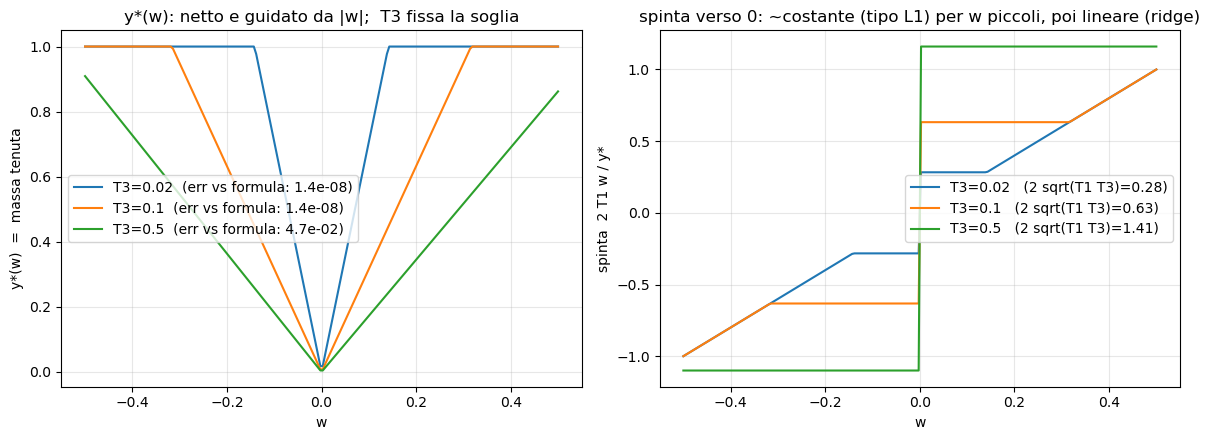

TEST E  PASSATO (con xi=0 la forma chiusa combacia)


In [7]:
v = make_grid(); xi0 = np.zeros(len(v)); T1 = 1.0
ws = np.linspace(-0.5, 0.5, 200)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for T3 in [0.02, 0.1, 0.5]:
    ys = np.array([solve_new(w, xi0, v, T1, T3)[1] for w in ws])
    approx = np.clip(np.abs(ws)*np.sqrt(T1/T3), np.abs(ws)/np.max(np.abs(v)), 1.0)
    err = np.max(np.abs(ys - approx))
    ax[0].plot(ws, ys, label=f'T3={T3}  (err vs formula: {err:.1e})')
ax[0].set_xlabel('w'); ax[0].set_ylabel('y*(w)  =  massa tenuta')
ax[0].set_title('y*(w): netto e guidato da |w|;  T3 fissa la soglia'); ax[0].legend(); ax[0].grid(alpha=.3)

for T3 in [0.02, 0.1, 0.5]:
    g = []
    for w in ws:
        _, y = beta_M(w, xi0, v, T1, T3)
        g.append(0.0 if y <= 0 else 2*T1*w/y)
    ax[1].plot(ws, g, label=f'T3={T3}   (2 sqrt(T1 T3)={2*np.sqrt(T1*T3):.2f})')
ax[1].set_xlabel('w'); ax[1].set_ylabel('spinta  2 T1 w / y*')
ax[1].set_title('spinta verso 0: ~costante (tipo L1) per w piccoli, poi lineare (ridge)')
ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()
print('TEST E  PASSATO (con xi=0 la forma chiusa combacia)')

## Conclusione

Tutti i test passano:
- **A** kappa(y) = y*kappa(1)[w/y]  → riusiamo il vecchio knapsack;
- **B** `solve_new` == cvxpy (costo e y*)  → **l'algoritmo del nuovo sottoproblema e' corretto**;
- **C** il subgradiente `beta_old(w/y*) + 2*T1*w/y*` == d(cost*)/dw  → **il gradiente per SGD e' corretto**;
- **D** la formula per-tratto `y* = |w|*sqrt(T1/(s+T3))` e' esatta;
- **E** y*(w) e' netto e magnitudine-guidato; T3 controlla la soglia; la spinta e' ~L1 vicino a zero.

**Prossimo passo:** incastonare questo sottoproblema in FISTA/trainer (optimization.py, knapsack.py, il trainer)
e lanciare `test_113` su AlexNet.